# Basic concepts - Nodes, Edges & States

In [3]:
from typing import TypedDict
from langgraph.graph import START, END, StateGraph

In [4]:
class InputState(TypedDict):
    string_value:str
    numeric_value: int

In [5]:
def modify_state(input: InputState):
    print(f"Current value: {input}")
    return input

In [6]:
graph = StateGraph(InputState)

graph.add_node("branch_a", modify_state)
graph.add_node("branch_b", modify_state)

graph.add_edge(START, "branch_a")
graph.add_edge("branch_a","branch_b")
graph.add_edge("branch_b", END)

graph.set_entry_point("branch_a")


In [7]:
runnable = graph.compile()

## Vusyakuze graph

In [8]:
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod

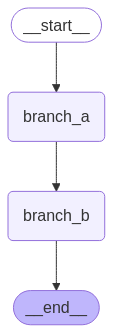

In [9]:
display(
    Image(
        runnable.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [10]:
runnable.invoke({"string_value": "a"})

Current value: {'string_value': 'a'}
Current value: {'string_value': 'a'}


{'string_value': 'a'}

In [11]:
runnable.invoke({"string_value": "a", "numeric_value": 1})

Current value: {'string_value': 'a', 'numeric_value': 1}
Current value: {'string_value': 'a', 'numeric_value': 1}


{'string_value': 'a', 'numeric_value': 1}

In [12]:
def modify_state(input: InputState):
    input["string_value"] += "a"
    input["numeric_value"] += 1
    return input


graph = StateGraph(InputState)

graph.add_node("branch_a", modify_state)
graph.add_node("branch_b", modify_state)
graph.add_edge("branch_a", "branch_b")
graph.add_edge("branch_b", END)


graph.set_entry_point("branch_a")

runnable = graph.compile()

In [13]:
try:
    runnable.invoke({"string_value": "a"})
except KeyError as e:
    print(e)

'numeric_value'


In [14]:
runnable.invoke({"string_value": "a", "numeric_value": 1})

{'string_value': 'aaa', 'numeric_value': 3}

## Cyrcles and conditional edges

In [15]:
def modify_state(input: InputState):
    input["string_value"] += "a"
    input["numeric_value"] += 1
    return input

def router(input:InputState):
    if input["numeric_value"] < 5:
        return "branch_a"
    else:
        return "__end__"

In [18]:
graph = StateGraph(InputState)

graph.add_node("branch_a", modify_state)
graph.add_node("branch_b", modify_state)
graph.add_edge("branch_a", "branch_b")
graph.add_conditional_edges(
    "branch_b", 
    router,
    {
        "branch_a": "branch_a",
        "__end__": END
    }
)
graph.set_entry_point("branch_a")

In [19]:
runnable = graph.compile()

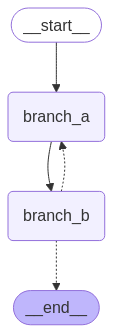

In [20]:
display(
    Image(
        runnable.get_graph().draw_mermaid_png(
            draw_method=MermaidDrawMethod.API,
        )
    )
)

In [21]:
runnable.invoke({"string_value": "a", "numeric_value": 1})

{'string_value': 'aaaaa', 'numeric_value': 5}

## Reducer functions

In [22]:
from typing import TypedDict, Annotated
from operator import add

In [23]:
class InputState(TypedDict):
    no_change_value:str
    string_value:Annotated[str,add]
    numeric_value: Annotated[int,add]
    list_value: Annotated[list[str],add]

In [24]:
def modify_state(input:InputState):
    return input

In [25]:
graph = StateGraph(InputState)

graph.add_node("branch_a", modify_state)
graph.add_node("branch_b", modify_state)
graph.add_edge("branch_a", "branch_b")
graph.add_edge("branch_b", END)

graph.set_entry_point("branch_a")

runnable = graph.compile()

In [26]:
runnable.invoke(
    {
        "no_change_value": "a",
        "string_value": "a",
        "numeric_value": 1,
        "list_value": ["a"],
    }
)

{'no_change_value': 'a',
 'string_value': 'aaaa',
 'numeric_value': 4,
 'list_value': ['a', 'a', 'a', 'a']}